# MNIST & MLP & CNN Robustness to Simple Transformations

## Part I: MLP
This notebook trains a simple multilayer perceptron (MLP) and an Convolutional Neural Network (CNN) on the MNIST dataset. It then evaluates how accuracy changes when we (1) shift the test images 4 pixels to the left and (2) invert image contrast by computing `255 - pixel`.

Tensorflow is the main library for learning and production. Researchers use Pytorch.

Keras is the high level API that makes coding easier. Since 2023 it is model agnistic (works with tensorflow, pytorch and Jax (the new google approach).

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## Load MNIST
Keras will download MNIST on first use (requires internet).

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)


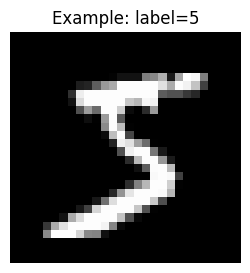

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print('Train:', x_train.shape, y_train.shape)
print('Test :', x_test.shape, y_test.shape)
# Quick peek
plt.figure(figsize=(3,3))
plt.imshow(x_train[0], cmap='gray')
plt.title(f'Example: label={y_train[0]}')
plt.axis('off')
plt.show()


## Build & Train a Simple MLP

In [ ]:
# Normalize to [0,1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32') / 255.0

We build our model. We need to specify before hand the **shape** of our data.
We stack as many **layers** as we consider, and add as many neurons as we consider. Usually multiple of 16, and sizes typically shrink as layers go deeper (e.g., 128 → 64 → 32).

**Relu** (recltified linear unit) is the standard **activation function**. This allow neurons to solve non linear problems.

In [ ]:
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(), # But a Dense layer expects a 1D vector. 28*28 = 784
    keras.layers.Dense(16, activation='relu'), # hidden layer
    keras.layers.Dense(10, activation='softmax') # we need 10 neurons in the output layer because we have 10 numbers to identify
]) # softmax transform the unnormalize log odds into probabilities so that we can interpret it.

We compile the model: state the optimizer, the loss, and the metric to evaluate. The **optimizer** moves the weights in the direction that reduces the loss. **"adam"** (adaptive movement estimation) is the standard. It adapts the learning rate to each weight.

**Loss** is the function we want to minimize, and there are many different ones. It is an important parameter. Generally, we use MSE or MAE for regressions, and binary or sparse cross-entropy for classifications.

https://keras.io/api/losses/

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,730 (49.73 KB)

 Trainable params: 12,730 (49.73 KB)

 Non-trainable params: 0 (0.00 B)

Have a look at the total number of parameters. Some more than traditional ML algorithms.

When **fitting** the model, we create an object that contains all the training and testing losses.

In [ ]:
history = model.fit(
    x_train_norm, y_train,
    validation_split=0.1,
    epochs=5,       # number of times the full fataset is passed forward
    batch_size=128, # how many observations are taken in each forward pass
    verbose=2,
    shuffle = True # default is true
)

test_loss, test_acc = model.evaluate(x_test_norm, y_test, verbose=0)
print(f'Baseline test accuracy: {test_acc:.4f}')

Epoch 1/5
422/422 - 2s - 6ms/step - accuracy: 0.7987 - loss: 0.7008 - val_accuracy: 0.9190 - val_loss: 0.3080
Epoch 2/5
422/422 - 1s - 3ms/step - accuracy: 0.9099 - loss: 0.3228 - val_accuracy: 0.9337 - val_loss: 0.2356
Epoch 3/5
422/422 - 1s - 3ms/step - accuracy: 0.9224 - loss: 0.2705 - val_accuracy: 0.9417 - val_loss: 0.2089
Epoch 4/5
422/422 - 1s - 3ms/step - accuracy: 0.9304 - loss: 0.2430 - val_accuracy: 0.9482 - val_loss: 0.1940
Epoch 5/5
422/422 - 1s - 3ms/step - accuracy: 0.9357 - loss: 0.2253 - val_accuracy: 0.9502 - val_loss: 0.1817
Baseline test accuracy: 0.9382


This tells us if we are over or underfitting, or if we need the model to train more **epochs**.

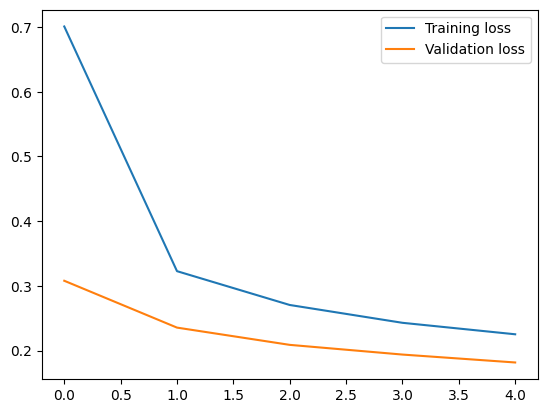

In [ ]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

Training too many epochs might lead to overfit. We can plot train and validation loss to find an adequate number. We can add also **callbacks** with **early stopping** when fitting the model. They monitor the validation loss and will stop the training when there is no improvement.


```
callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)]
```



You have programed your fiest neural network. The test accuracy seems good, but, [Is it though?](https://tenor.com/view/marvel-is-it-though-thor-bruce-banner-gif-14242312)

## Transformation 1: Shift test images 4 pixels to the left
We will shift the test images a 4 pixels to the left to put the model to the test. We zero-fill the rightmost 4 columns after shifting left.

In [ ]:
def shift_left(images, pixels=4):
    """
    Shift images left by `pixels`, zero-filling the right.
    images: (N, 28, 28) uint8 or float array in [0,255]
    Returns same dtype.
    """
    shifted = np.zeros_like(images)
    if pixels >= 28:
        return shifted
    shifted[:, :, :-pixels] = images[:, :, pixels:]
    return shifted

x_test_shifted = shift_left(x_test, pixels=4)
x_test_shifted_norm = x_test_shifted.astype('float32') / 255.0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


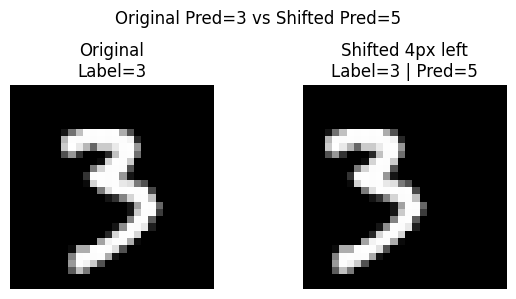

In [ ]:
# Visualize one original vs shifted side by side
idx = 30  # change this index to inspect other samples
fig, axes = plt.subplots(1, 2, figsize=(6,3))
axes[0].imshow(x_test[idx], cmap='gray')
axes[0].set_title(f'Original\nLabel={y_test[idx]}')
axes[0].axis('off')
axes[1].imshow(x_test_shifted[idx], cmap='gray')
orig_pred = np.argmax(model.predict(x_test_norm[idx:idx+1]), axis=-1)[0]
shift_pred = np.argmax(model.predict(x_test_shifted_norm[idx:idx+1]), axis=-1)[0]
axes[1].set_title(f'Shifted 4px left\nLabel={y_test[idx]} | Pred={shift_pred}')
axes[1].axis('off')
plt.suptitle(f'Original Pred={orig_pred} vs Shifted Pred={shift_pred}')
plt.tight_layout()
plt.show()


We apply the model to the shifted test dataset.

In [ ]:
loss_shift, acc_shift = model.evaluate(x_test_shifted_norm, y_test, verbose=0)
print(f'Accuracy on test set shifted 4px left: {acc_shift:.4f}')

Accuracy on test set shifted 4px left: 0.3206


Bummer.